In [42]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Downloading Data
- Note: We will be using Apple's Stock price for this Mini-Project.

In [72]:
ticker = "AAPL"

data = yf.download(
    ticker,
    start="2015-01-01", 
    end="2026-03-01" #Nearly 11years of Data
)[["Close", "Volume", "High", "Low", "Open"]]

# Removing MultiIndex if present
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

print(data.head(), end="\n\n")
print(data.tail(),end="\n\n")
print(data.info())

[*********************100%***********************]  1 of 1 completed

Price           Close     Volume       High        Low       Open
Date                                                             
2015-01-02  24.214899  212818400  24.682231  23.776359  24.671157
2015-01-05  23.532717  257142000  24.064280  23.346671  23.984545
2015-01-06  23.534941  263188400  23.794077  23.173920  23.596956
2015-01-07  23.864948  160423600  23.964616  23.632389  23.743131
2015-01-08  24.781895  237458000  24.839481  24.075359  24.192747

Price            Close    Volume        High         Low        Open
Date                                                                
2026-02-23  266.179993  37308200  269.429993  263.380005  263.489990
2026-02-24  272.140015  47014600  274.890015  267.709991  267.859985
2026-02-25  274.230011  33714300  274.940002  271.049988  271.779999
2026-02-26  272.950012  32345100  276.109985  270.799988  274.950012
2026-02-27  264.179993  72366500  272.809998  262.890015  272.809998

<class 'pandas.DataFrame'>
DatetimeIndex: 2805 entrie

### Data-Cleansing

In [73]:
data = data.ffill() #Forward Filling data due to market might be closed on some-days and the price of stock will be same on these holidays.

print("Shape:", data.shape)
print("Number of NaN values left:", data.isna().sum().sum())

Shape: (2805, 5)
Number of NaN values left: 0


## Data Analysis
We will analyse stock on 2 metrics:
* 25 days - Exponential Moving Average (EMA):
  * The Exponential Moving Average (EMA) is a trend-following technical indicator that calculates the average price over a specific period, heavily weighting the most recent data to respond faster to price changes than a Simple Moving Average (SMA).
  * It identifies trend direction, momentum strength, and potential support/resistance levels, with shorter-term EMAs (e.g., 9-day) responding faster than long-term ones (e.g., 200-day).
  * Formula:
    EMA_today = (Price_today * k) + (EMA_yesterday * (1 - k))

    Where:
    - k = 2 / (N + 1)
    - N = Number of periods (e.g., 10, 20, or 50 days)

  ---
* Relative Strength Index (RSI):
  * The Relative Strength Index (RSI) is a popular technical analysis momentum oscillator ranging from 0 to 100, used to measure the speed and magnitude of recent price changes to evaluate overvalued or undervalued conditions in an asset.
  * Traditionally, an RSI reading above 70 indicates an asset is overbought (potentially overvalued and due for a pullback), while a reading below 30 indicates it is oversold (undervalued and possibly due for a bounce).
  * Formula:
    RSI = 100 - (100 / (1 + RS))

    Where:
    - RS (Relative Strength) = Average Gain / Average Loss
    - Average Gain = (Sum of Gains over N periods) / N
    - Average Loss = (Sum of Losses over N periods) / N
    - N = Look-back period (standard is 14)

In [74]:
# Computing EMA on 25-days window
data["EMA_25"] = data["Close"].ewm(span=25, adjust=False).mean()

# Computing RSI
window = 14
delta = data['Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(window=window).mean()
avg_loss = loss.rolling(window=window).mean()
rs = avg_gain / avg_loss
data["RSI"] = 100 - (100 / (1 + rs))

data["EMA_25"].head(), data["RSI"].tail()

(Date
 2015-01-02    24.214899
 2015-01-05    24.162424
 2015-01-06    24.114156
 2015-01-07    24.094986
 2015-01-08    24.147825
 Name: EMA_25, dtype: float64,
 Date
 2026-02-23    46.686194
 2026-02-24    52.450670
 2026-02-25    48.163678
 2026-02-26    47.552395
 2026-02-27    38.924889
 Name: RSI, dtype: float64)

## Visualising Data-Metrics

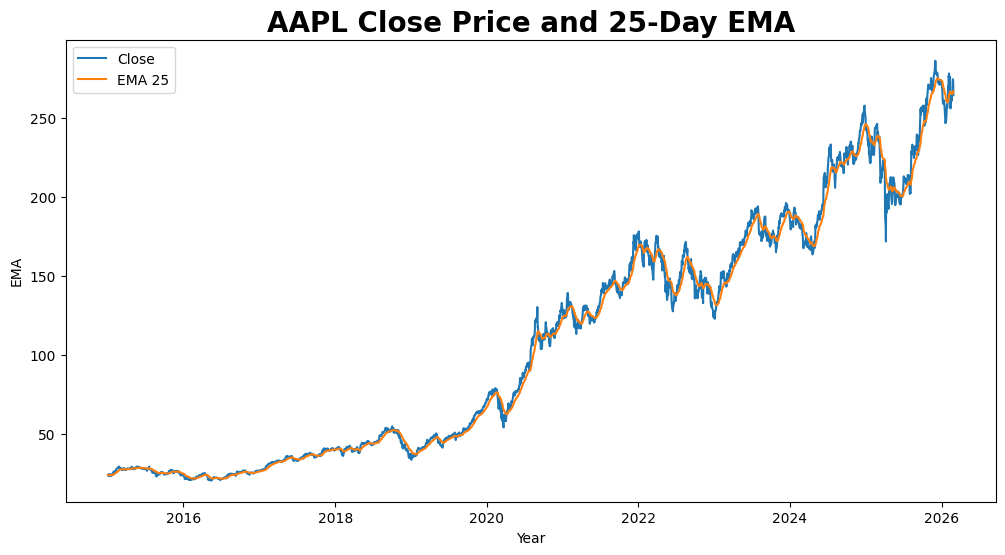

In [75]:
plt.figure(figsize=(12,6))
plt.plot(data['Close'], label='Close')
plt.plot(data['EMA_25'], label='EMA 25')
plt.title(f"{ticker} Close Price and 25-Day EMA", fontweight="bold", fontsize=20)
plt.xlabel("Year")
plt.ylabel("EMA")
plt.legend()
plt.show()

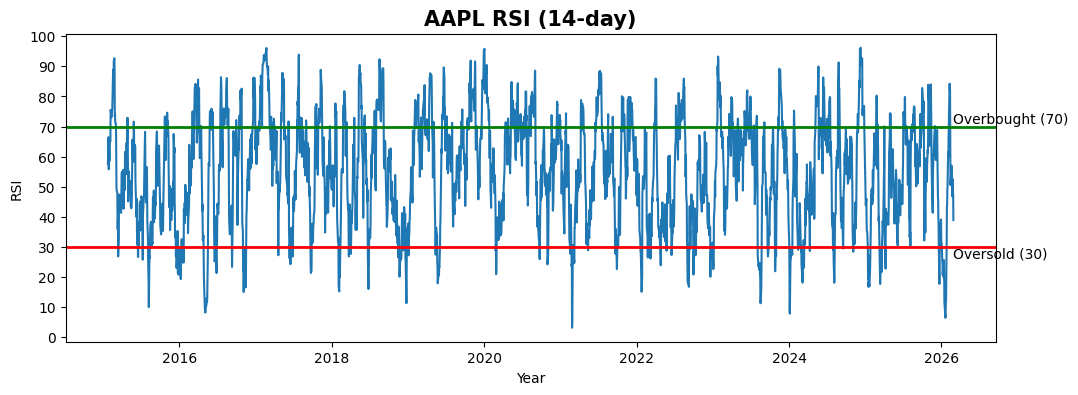

In [76]:
fig, ax = plt.subplots(figsize=(12,4))

ax.plot(data['RSI'])
ax.axhline(70, color="g", lw=2)
ax.axhline(30, color="r", lw=2)

ax.text(x=data.index[-1], y=70, s="Overbought (70)", verticalalignment="bottom")

ax.text(x=data.index[-1], y=30, s="Oversold (30)", verticalalignment="top")

ax.set_title(f"{ticker} RSI (14-day)", fontweight="bold", fontsize=15)
ax.set_xlabel("Year")
ax.set_ylabel("RSI")
ax.set_yticks(np.arange(0,110,10))
plt.show()

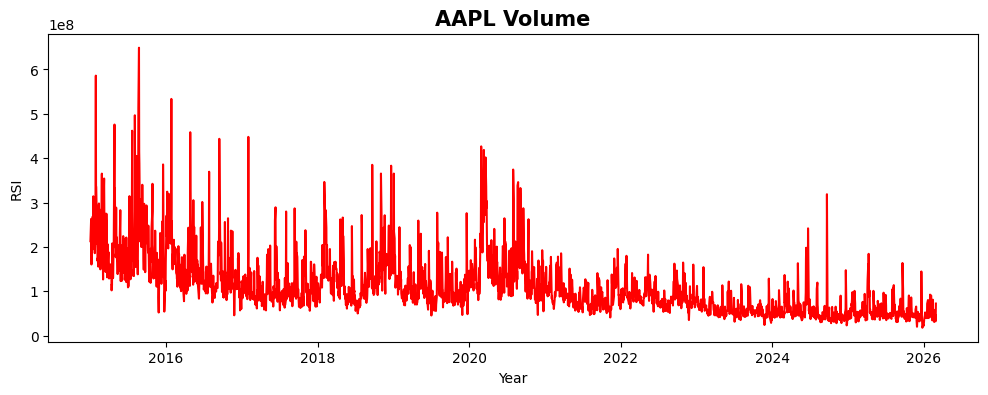

In [77]:
plt.figure(figsize=(12,4))
plt.plot(data['Volume'], c="r")
plt.title(f"{ticker} Volume", fontweight="bold", fontsize=15)
plt.xlabel("Year")
plt.ylabel("RSI")
plt.show()

## Data Pre-Processing

In [78]:
# Target Column
target_column = "Close"

# Price range (volatility proxy)
data["HL_range"] = data["High"] - data["Low"]

# Intraday momentum
data["OC_diff"] = data["Open"] - data["Close"]

# Volume normalization
data["Vol_MA_30"] = data["Volume"].rolling(window=30).mean()
data["Vol_norm"] = data["Volume"] / data["Vol_MA_30"]

# Drop temporary column if desired
data = data.drop(columns=["Vol_MA_30"])

data = data.dropna()

In [79]:
features = [
    "Close",
    "HL_range",
    "OC_diff",
    "Vol_norm"
]

data = data[features]

data

Price,Close,HL_range,OC_diff,Vol_norm
Date,,,,
2015-02-13,28.257332,0.362444,0.044471,0.866402
2015-02-17,28.424101,0.435824,-0.075603,1.002857
2015-02-18,28.621988,0.295737,-0.242372,0.720272
2015-02-19,28.561956,0.155650,0.006670,0.608724
2015-02-20,28.795433,0.322419,-0.195677,0.793677
...,...,...,...,...
2026-02-23,266.179993,6.049988,-2.690002,0.695646
2026-02-24,272.140015,7.180023,-4.280029,0.872823
2026-02-25,274.230011,3.890015,-2.450012,0.630410


## Creating Train-Val-Test Split

In [80]:
# Converting to numpy
dataset = data.values

n_total = len(dataset)
train_size = int(n_total * 0.8)
val_size = int(n_total * 0.1)

train_data = dataset[:train_size]
val_data = dataset[train_size:train_size + val_size]
test_data = dataset[train_size + val_size:]

print(train_data.shape, val_data.shape, test_data.shape)

(2220, 4) (277, 4) (279, 4)


## Min-Max Scaling the Data

In [81]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

In [82]:
def create_sequences(data, seq_length=60):
    X = []
    y = []

    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i, 0])  # Close is column 0

    return np.array(X), np.array(y)

seq_length = 60

X_train, y_train = create_sequences(train_scaled, seq_length)
X_val, y_val = create_sequences(val_scaled, seq_length)
X_test, y_test = create_sequences(test_scaled, seq_length)

print(X_train.shape, y_train.shape)
print("Input shape:", X_train[0].shape)
print("Target value:", y_train[0])

(2160, 60, 4) (2160,)
Input shape: (60, 4)
Target value: 0.04338815341700336


### Loading Dependencies

In [83]:
import torch as t
from torch.utils.data import DataLoader, TensorDataset
from torch import nn, optim
from torch.utils.tensorboard import SummaryWriter

### Converting Numpy Arrays to Torch Tensors

In [84]:
X_train = t.tensor(X_train, dtype=t.float32)
y_train = t.tensor(y_train, dtype=t.float32).unsqueeze(dim=1)

X_val = t.tensor(X_val, dtype=t.float32)
y_val = t.tensor(y_val, dtype=t.float32).unsqueeze(dim=1)

X_test = t.tensor(X_test, dtype=t.float32)
y_test = t.tensor(y_test, dtype=t.float32).unsqueeze(dim=1)

### Converting Input and Output values in Iterable Torch Datasets for torch dataloaders

In [85]:
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

### Creating Dataloaders

In [86]:
Batch_size = 64

t.manual_seed(42)
train_loader = DataLoader(train_dataset, batch_size=Batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=Batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=Batch_size, shuffle=False)

## Gated Recurrent Unit (GRU) Code, Model Class

In [87]:
class GRUModel(nn.Module):
    def __init__(self, input_size=4, hidden_size=128, num_layers=2, dropout=0.2):
        super(GRUModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # GRU layer
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x:t.Tensor) -> t.Tensor:
        # x ==> (batch_size, seq_len, input_size)

        # Initializing hidden state
        h0 = t.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Forward Prop
        out, _ = self.gru(x, h0)

        # Take last time step output
        out = out[:, -1, :]

        # Final prediction
        out = self.fc(out)

        return out

## Training and Validating the Model

In [89]:
import time

start_time = time.time()

device = t.device("cuda" if t.cuda.is_available() else "cpu")
model = GRUModel(input_size=4, hidden_size=128, num_layers=2, dropout=0.2).to(device)

epochs = 100
alpha = 0.01

loss_func = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=alpha)

writer = SummaryWriter(log_dir="runs/predictor")

dummy_input = t.zeros(1, 60, 4).to(device)
writer.add_graph(model, dummy_input)

for epoch in range(epochs):

    # ---- TRAIN ----
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = loss_func(outputs, y_batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_loader.dataset)

    # ---- VALIDATION ----
    model.eval()
    val_loss = 0.0

    with t.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = loss_func(outputs, y_batch)

            val_loss += loss.item() * X_batch.size(0)

    val_loss /= len(val_loader.dataset)

    # ---- LOGGING ----
    writer.add_scalar("Loss Train", train_loss, epoch)
    writer.add_scalar("Loss Validation", val_loss, epoch)
    if((epoch+1)%20 == 0):
        print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.6f} "
          f"Val Loss: {val_loss:.6f}")

writer.close()

end_time = time.time() - start_time

print(f"\nTime Taken to Train: {end_time:.3f} seconds")

Epoch [20/100] Train Loss: 0.000260 Val Loss: 0.003670
Epoch [40/100] Train Loss: 0.000238 Val Loss: 0.002566
Epoch [60/100] Train Loss: 0.000269 Val Loss: 0.000515
Epoch [80/100] Train Loss: 0.000218 Val Loss: 0.001013
Epoch [100/100] Train Loss: 0.000176 Val Loss: 0.000572

Time Taken to Train: 5.552 seconds


## Evaluating the Model

In [90]:
model.eval()
predictions = []
actuals = []

with t.inference_mode():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        predictions.append(outputs.cpu())
        actuals.append(y_batch)

predictions = t.cat(predictions).numpy()
actuals = t.cat(actuals).numpy()

### Inverse scaling predictions

In [91]:
def inverse_close(scaled_close, scaler):
    dummy = np.zeros((len(scaled_close), 4))
    dummy[:, 0] = scaled_close.squeeze()
    inverted = scaler.inverse_transform(dummy)
    return inverted[:, 0]

pred_inv = inverse_close(predictions, scaler)
actual_inv = inverse_close(actuals, scaler)

## Printing Metrics

In [92]:
rmse = np.sqrt(((actual_inv-pred_inv)**2).mean())
mae = abs(actual_inv-pred_inv).mean()

print("Test RMSE:", rmse)
print("Test MAE:", mae)

Test RMSE: 10.222784872756042
Test MAE: 8.336979164159084


## Plotting Actual Vs Predictions Graph

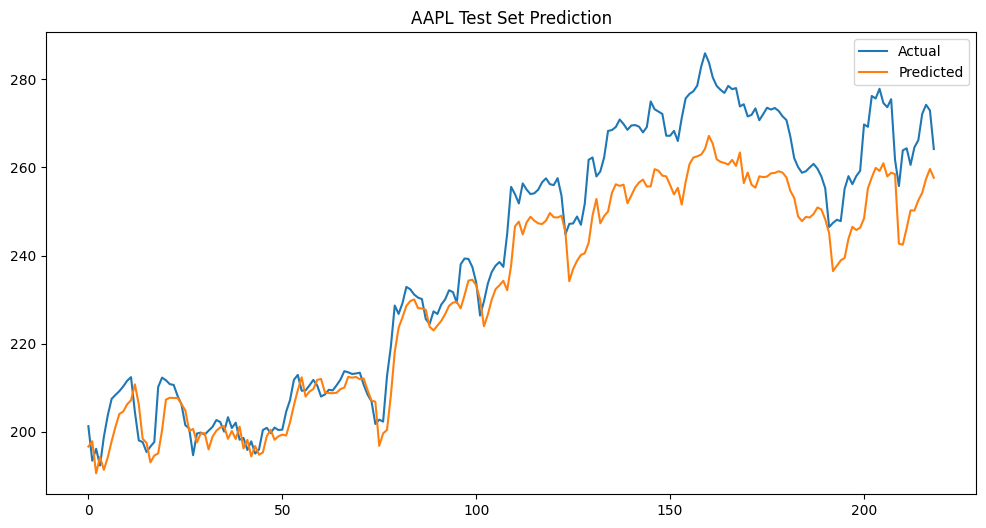

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(actual_inv, label="Actual")
plt.plot(pred_inv, label="Predicted")
plt.title("AAPL Test Set Prediction")
plt.legend()
plt.show()